In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

# Full model comparison — all pipelines

Aggregates every model from all three pipelines (**Text**, **Image**, **Multimodal**) into
a single comparison. Loads all `_meta.json` files from `models/text/json/`,
`models/images/json/`, and `models/both/json/`.

**Important caveat — read before interpreting cross-pipeline numbers.** The text-only and
image-only pipelines were each evaluated on their own independent train/test split (same
stratification parameters, but different DataFrame orderings → different tweets in the test
set). The multimodal pipeline uses a single *joint* split so its two base models see the
same tweets. Concretely, GloVe+LSTM scores 0.733 on the text-only split but 0.707 on the
joint multimodal split — that ~2.6-point gap is split variation, not a real difference.
Cross-pipeline accuracy differences smaller than a few points should not be over-interpreted.

## Load metadata from all three pipelines

In [2]:
pipelines = {
    'text':   'Text',
    'images': 'Image',
    'both':   'Multimodal',
}

records = []
for folder, pipe_label in pipelines.items():
    d = f'../models/{folder}/json'
    for fname in sorted(os.listdir(d)):
        if not fname.endswith('_meta.json'):
            continue
        with open(os.path.join(d, fname)) as f:
            m = json.load(f)
        m['Pipeline'] = pipe_label
        records.append(m)

df = pd.DataFrame(records)

# The majority-class baseline is identical across pipelines (same labels, same stratified
# split parameters -> 0.363). Collapse the duplicates into one 'Baseline' reference row.
base_mask = df['model'] == 'baseline'
if base_mask.sum() > 0:
    keep = df[base_mask].iloc[[0]].copy()
    keep['Pipeline'] = 'Baseline'
    df = pd.concat([df[~base_mask], keep], ignore_index=True)

name_map = {
    'baseline':                    'Baseline',
    'naive_bayes':                 'Naive Bayes',
    'logistic_regression':         'Logistic Regression',
    'svm':                         'SVM',
    'mlp_text':                    'MLP',
    'rnn_text':                    'RNN (plain)',
    'glove_rnn_text':              'GloVe+LSTM',
    'cnn_scratch':                 'CNN (scratch)',
    'cnn_mobilenet':               'MobileNetV2',
    'cnn_efficientnet':            'EfficientNetB0',
    'multimodal_late_fusion':      'Late Fusion (avg)',
    'multimodal_weighted_fusion':  'Weighted Fusion',
    'multimodal_stacking':         'Stacking',
}
df['Model'] = df['model'].map(name_map)

df = df.rename(columns={
    'accuracy':    'Accuracy',
    'macro_f1':    'Macro F1',
    'negative_f1': 'Neg F1',
    'neutral_f1':  'Neu F1',
    'positive_f1': 'Pos F1',
    'runtime_seconds': 'Runtime (s)',
})

# Pipeline colour scheme used by every chart below
pipeline_palette = {
    'Baseline':   '#bdbdbd',
    'Text':       '#4c72b0',
    'Image':      '#dd8452',
    'Multimodal': '#55a868',
}
pipeline_order = ['Baseline', 'Text', 'Image', 'Multimodal']

df = df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
baseline_acc = df.loc[df['Model'] == 'Baseline', 'Accuracy'].values[0]
print(f'Loaded {len(df)} models across {df["Pipeline"].nunique()} pipeline groups.')
print(f'Majority-class baseline accuracy: {baseline_acc:.3f}')

Loaded 13 models across 4 pipeline groups.
Majority-class baseline accuracy: 0.363


## Table 1 — All results, with originating pipeline

Every model from every pipeline, sorted by test accuracy.

In [3]:
summary = df[['Model', 'Pipeline', 'Accuracy', 'Macro F1', 'Neg F1', 'Neu F1', 'Pos F1', 'Runtime (s)']].copy()
summary.index = range(1, len(summary) + 1)
summary.round(3)

,Model,Pipeline,Accuracy,Macro F1,Neg F1,Neu F1,Pos F1,Runtime (s)
1,GloVe+LSTM,Text,0.733,0.732,0.719,0.673,0.805,169.950
2,Stacking,Multimodal,0.707,0.710,0.681,0.645,0.804,235.667
3,Logistic Regression,Text,0.700,0.701,0.683,0.646,0.774,1.350
4,Weighted Fusion,Multimodal,0.695,0.696,0.673,0.637,0.779,276.752
5,SVM,Text,0.682,0.682,0.654,0.620,0.772,3.231
6,Late Fusion (avg),Multimodal,0.677,0.675,0.634,0.637,0.754,431.860
7,Naive Bayes,Text,0.672,0.670,0.651,0.615,0.742,0.044
8,MLP,Text,0.664,0.666,0.657,0.609,0.733,419.390
9,MobileNetV2,Image,0.419,0.418,0.393,0.431,0.431,1771.031
10,RNN (plain),Text,0.383,0.223,0.128,0.540,0.000,90.378


## Table 2 — Rankings by metric

In [4]:
metrics = ['Accuracy', 'Macro F1', 'Neg F1', 'Neu F1', 'Pos F1']
ranks = pd.DataFrame({'Model': df['Model'], 'Pipeline': df['Pipeline']})
for m in metrics:
    ranks[m] = df[m].rank(ascending=False, method='min').astype(int)
ranks.index = range(1, len(ranks) + 1)
ranks

,Model,Pipeline,Accuracy,Macro F1,Neg F1,Neu F1,Pos F1
1,GloVe+LSTM,Text,1,1,1,1,1
2,Stacking,Multimodal,2,2,3,3,2
3,Logistic Regression,Text,3,3,2,2,4
4,Weighted Fusion,Multimodal,4,4,4,5,3
5,SVM,Text,5,5,6,6,5
6,Late Fusion (avg),Multimodal,6,6,8,4,6
7,Naive Bayes,Text,7,7,7,7,7
8,MLP,Text,8,8,5,8,8
9,MobileNetV2,Image,9,9,9,12,9
10,RNN (plain),Text,10,11,11,9,11


## Table 3 — Gain over baseline

In [5]:
gains = df[df['Model'] != 'Baseline'][['Model', 'Pipeline', 'Accuracy', 'Macro F1']].copy()
gains['Accuracy Gain'] = (gains['Accuracy'] - baseline_acc).round(3)
gains['Accuracy'] = gains['Accuracy'].round(3)
gains['Macro F1'] = gains['Macro F1'].round(3)
gains = gains.sort_values('Accuracy Gain', ascending=False).reset_index(drop=True)
gains.index = range(1, len(gains) + 1)
gains

,Model,Pipeline,Accuracy,Macro F1,Accuracy Gain
1,GloVe+LSTM,Text,0.733,0.732,0.370
2,Stacking,Multimodal,0.707,0.710,0.344
3,Logistic Regression,Text,0.700,0.701,0.337
4,Weighted Fusion,Multimodal,0.695,0.696,0.332
5,SVM,Text,0.682,0.682,0.318
6,Late Fusion (avg),Multimodal,0.677,0.675,0.313
7,Naive Bayes,Text,0.672,0.670,0.309
8,MLP,Text,0.664,0.666,0.301
9,MobileNetV2,Image,0.419,0.418,0.055
10,RNN (plain),Text,0.383,0.223,0.020


## Table 4 — Per-class F1 detail

In [6]:
f1_detail = df[['Model', 'Pipeline', 'Neg F1', 'Neu F1', 'Pos F1']].copy()
f1_detail['Best Class']  = f1_detail[['Neg F1', 'Neu F1', 'Pos F1']].idxmax(axis=1).str.replace(' F1', '')
f1_detail['Worst Class'] = f1_detail[['Neg F1', 'Neu F1', 'Pos F1']].idxmin(axis=1).str.replace(' F1', '')
f1_detail = f1_detail.reset_index(drop=True)
f1_detail.index = range(1, len(f1_detail) + 1)
f1_detail.round(3)

,Model,Pipeline,Neg F1,Neu F1,Pos F1,Best Class,Worst Class
1,GloVe+LSTM,Text,0.719,0.673,0.805,Pos,Neu
2,Stacking,Multimodal,0.681,0.645,0.804,Pos,Neu
3,Logistic Regression,Text,0.683,0.646,0.774,Pos,Neu
4,Weighted Fusion,Multimodal,0.673,0.637,0.779,Pos,Neu
5,SVM,Text,0.654,0.620,0.772,Pos,Neu
6,Late Fusion (avg),Multimodal,0.634,0.637,0.754,Pos,Neg
7,Naive Bayes,Text,0.651,0.615,0.742,Pos,Neu
8,MLP,Text,0.657,0.609,0.733,Pos,Neu
9,MobileNetV2,Image,0.393,0.431,0.431,Neu,Neg
10,RNN (plain),Text,0.128,0.540,0.000,Neu,Pos


## Table 5 — Pipeline champions

The single best model (by accuracy) from each pipeline. This is the head-to-head that
answers the project's central question: which representation of the same tweet carries
the most predictable sentiment?

In [7]:
champ_pool = df[df['Pipeline'] != 'Baseline']
champions = champ_pool.loc[champ_pool.groupby('Pipeline')['Accuracy'].idxmax()]
champions = champions[['Pipeline', 'Model', 'Accuracy', 'Macro F1', 'Runtime (s)']]
champions['Pipeline'] = pd.Categorical(champions['Pipeline'], categories=['Text', 'Image', 'Multimodal'], ordered=True)
champions = champions.sort_values('Pipeline').reset_index(drop=True)
champions.index = range(1, len(champions) + 1)
champions.round(3)

,Pipeline,Model,Accuracy,Macro F1,Runtime (s)
1,Text,GloVe+LSTM,0.733,0.732,169.950
2,Image,MobileNetV2,0.419,0.418,1771.031
3,Multimodal,Stacking,0.707,0.710,235.667


## Table 6 — Pipeline summary statistics

In [8]:
rows = []
for pipe in ['Text', 'Image', 'Multimodal']:
    sub = df[df['Pipeline'] == pipe]
    best = sub.loc[sub['Accuracy'].idxmax()]
    rows.append({
        'Pipeline':      pipe,
        '# Models':      len(sub),
        'Best Accuracy': round(best['Accuracy'], 3),
        'Best Model':    best['Model'],
        'Mean Accuracy': round(sub['Accuracy'].mean(), 3),
        'Worst Accuracy':round(sub['Accuracy'].min(), 3),
    })
stats_df = pd.DataFrame(rows)
stats_df.index = range(1, len(stats_df) + 1)
stats_df

,Pipeline,# Models,Best Accuracy,Best Model,Mean Accuracy,Worst Accuracy
1,Text,6,0.733,GloVe+LSTM,0.639,0.383
2,Image,3,0.419,MobileNetV2,0.384,0.363
3,Multimodal,3,0.707,Stacking,0.693,0.677


## Chart 1 — Accuracy comparison, colour-coded by pipeline

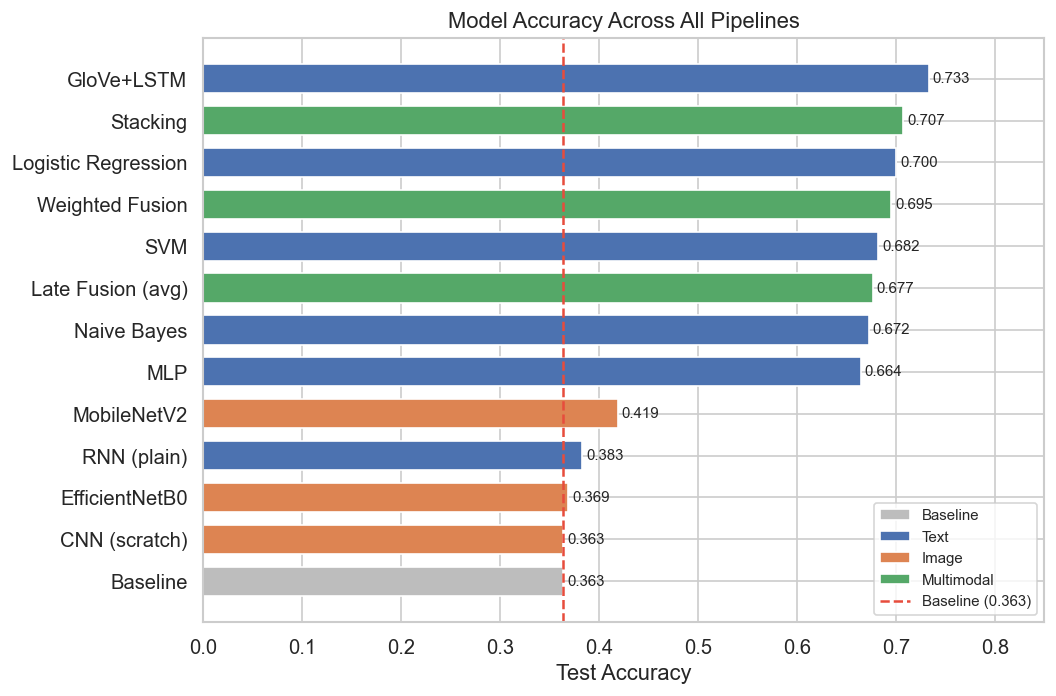

In [9]:
fig, ax = plt.subplots(figsize=(9, 6))
plot_df = df.sort_values('Accuracy')
bars = ax.barh(
    plot_df['Model'], plot_df['Accuracy'],
    color=[pipeline_palette[p] for p in plot_df['Pipeline']], edgecolor='white', height=0.7
)
ax.axvline(baseline_acc, color='#e74c3c', linestyle='--', linewidth=1.5)
for bar, val in zip(bars, plot_df['Accuracy']):
    ax.text(bar.get_width() + 0.004, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9)
ax.set_xlabel('Test Accuracy')
ax.set_title('Model Accuracy Across All Pipelines')
ax.set_xlim(0, 0.85)
legend_elements = [Patch(facecolor=pipeline_palette[p], label=p) for p in pipeline_order]
legend_elements.append(plt.Line2D([0], [0], color='#e74c3c', linestyle='--', label=f'Baseline ({baseline_acc:.3f})'))
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

## Chart 2 — Per-class F1 by model

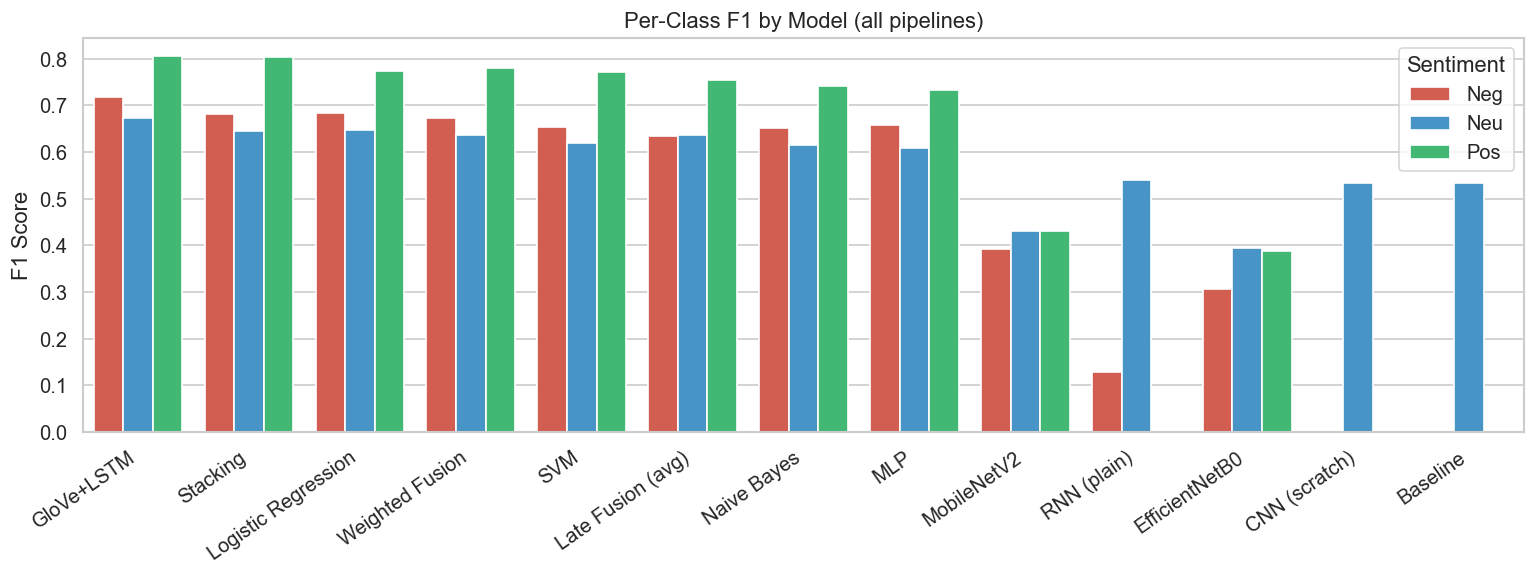

In [10]:
f1_melt = df.melt(
    id_vars='Model', value_vars=['Neg F1', 'Neu F1', 'Pos F1'],
    var_name='Class', value_name='F1'
)
f1_melt['Class'] = f1_melt['Class'].str.replace(' F1', '')
order = df['Model'].tolist()

fig, ax = plt.subplots(figsize=(13, 5))
sns.barplot(
    data=f1_melt, x='Model', y='F1', hue='Class', order=order,
    palette={'Neg': '#e74c3c', 'Neu': '#3498db', 'Pos': '#2ecc71'},
    ax=ax, edgecolor='white'
)
ax.set_xlabel('')
ax.set_ylabel('F1 Score')
ax.set_title('Per-Class F1 by Model (all pipelines)')
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, rotation=35, ha='right')
ax.legend(title='Sentiment')
plt.tight_layout()
plt.show()

## Chart 3 — Metrics heatmap

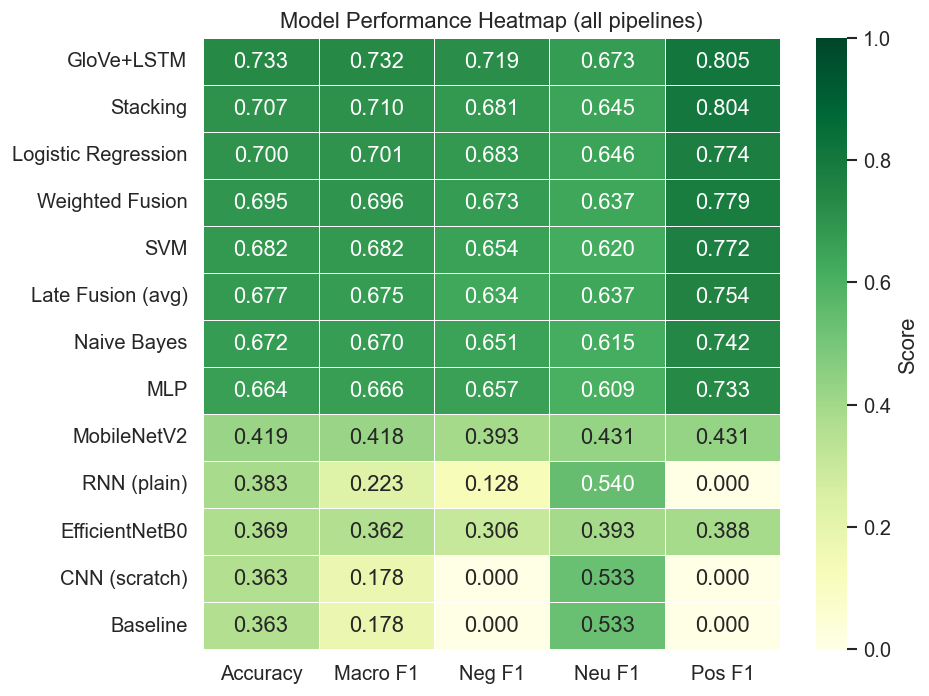

In [11]:
heat_df = df.set_index('Model')[['Accuracy', 'Macro F1', 'Neg F1', 'Neu F1', 'Pos F1']].round(3)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    heat_df, annot=True, fmt='.3f', cmap='YlGn',
    linewidths=0.5, linecolor='white',
    vmin=0, vmax=1, ax=ax, cbar_kws={'label': 'Score'}
)
ax.set_title('Model Performance Heatmap (all pipelines)')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## Chart 4 — Accuracy vs. runtime tradeoff

Coloured by pipeline. Runtime is on a log scale (baseline is near-instant; deep models
take minutes).

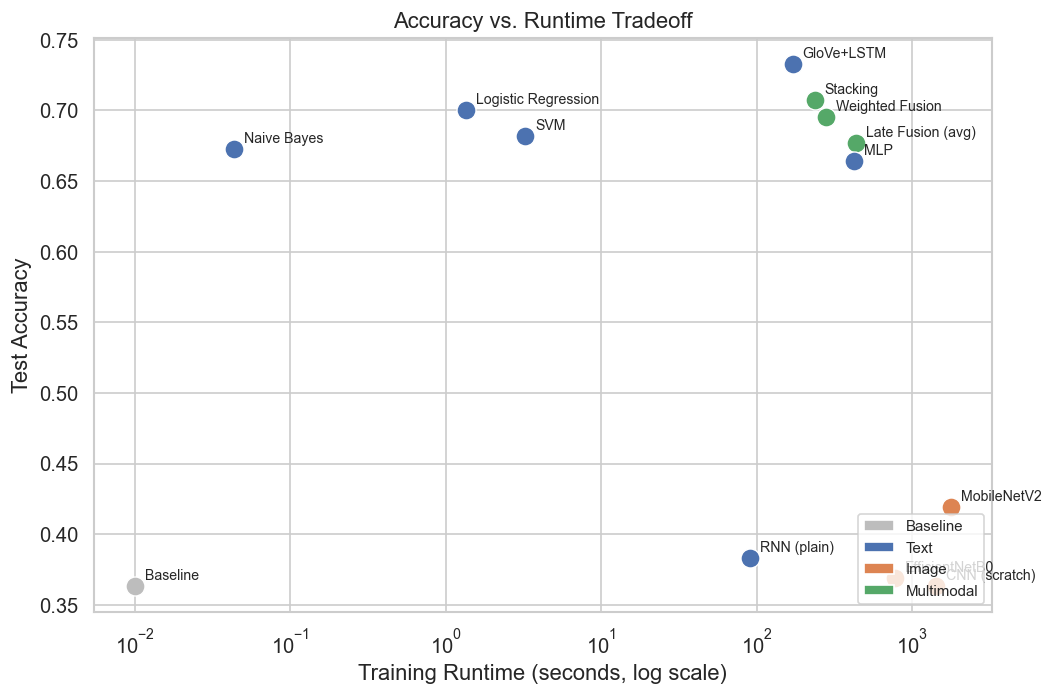

In [12]:
fig, ax = plt.subplots(figsize=(9, 6))
for _, row in df.iterrows():
    rt = max(row['Runtime (s)'], 0.01)  # keep baseline visible on log axis
    ax.scatter(rt, row['Accuracy'], color=pipeline_palette[row['Pipeline']],
               s=130, zorder=3, edgecolors='white', linewidth=0.8)
    ax.annotate(row['Model'], (rt, row['Accuracy']),
                textcoords='offset points', xytext=(6, 4), fontsize=8.5)
ax.set_xscale('log')
ax.set_xlabel('Training Runtime (seconds, log scale)')
ax.set_ylabel('Test Accuracy')
ax.set_title('Accuracy vs. Runtime Tradeoff')
legend_elements = [Patch(facecolor=pipeline_palette[p], label=p) for p in pipeline_order]
ax.legend(handles=legend_elements, fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()

## Chart 5 — Gain over baseline

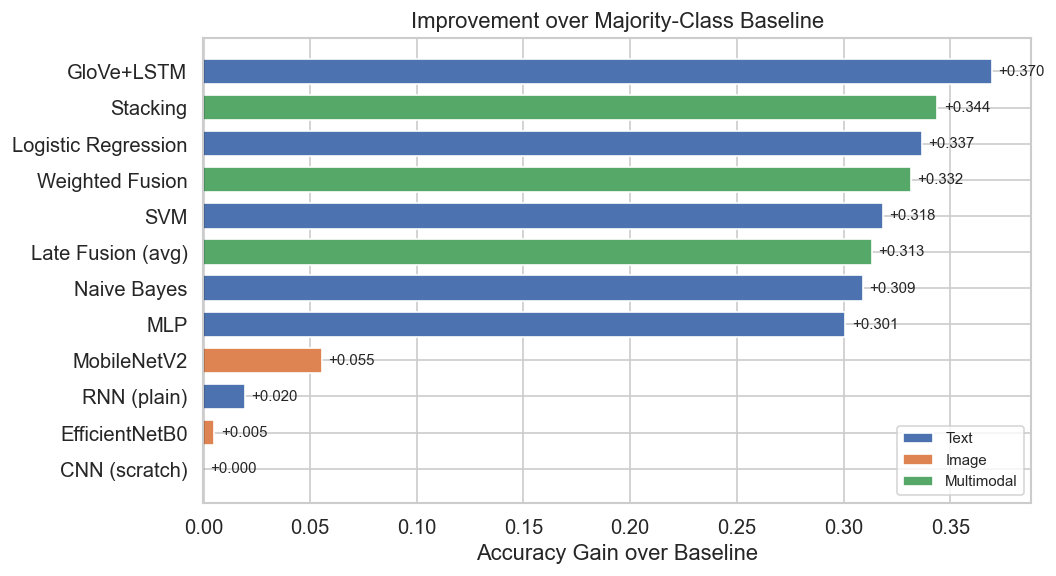

In [13]:
gain_df = df[df['Model'] != 'Baseline'].copy()
gain_df['Accuracy Gain'] = gain_df['Accuracy'] - baseline_acc
gain_df = gain_df.sort_values('Accuracy Gain')

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(
    gain_df['Model'], gain_df['Accuracy Gain'],
    color=[pipeline_palette[p] for p in gain_df['Pipeline']], edgecolor='white', height=0.7
)
for bar, val in zip(bars, gain_df['Accuracy Gain']):
    offset = 0.003 if val >= 0 else -0.003
    ha = 'left' if val >= 0 else 'right'
    ax.text(bar.get_width() + offset, bar.get_y() + bar.get_height() / 2,
            f'{val:+.3f}', va='center', ha=ha, fontsize=9)
ax.set_xlabel('Accuracy Gain over Baseline')
ax.set_title('Improvement over Majority-Class Baseline')
ax.axvline(0, color='black', linewidth=0.8)
legend_elements = [Patch(facecolor=pipeline_palette[p], label=p) for p in ['Text', 'Image', 'Multimodal']]
ax.legend(handles=legend_elements, fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()

## Chart 6 — Runtime comparison

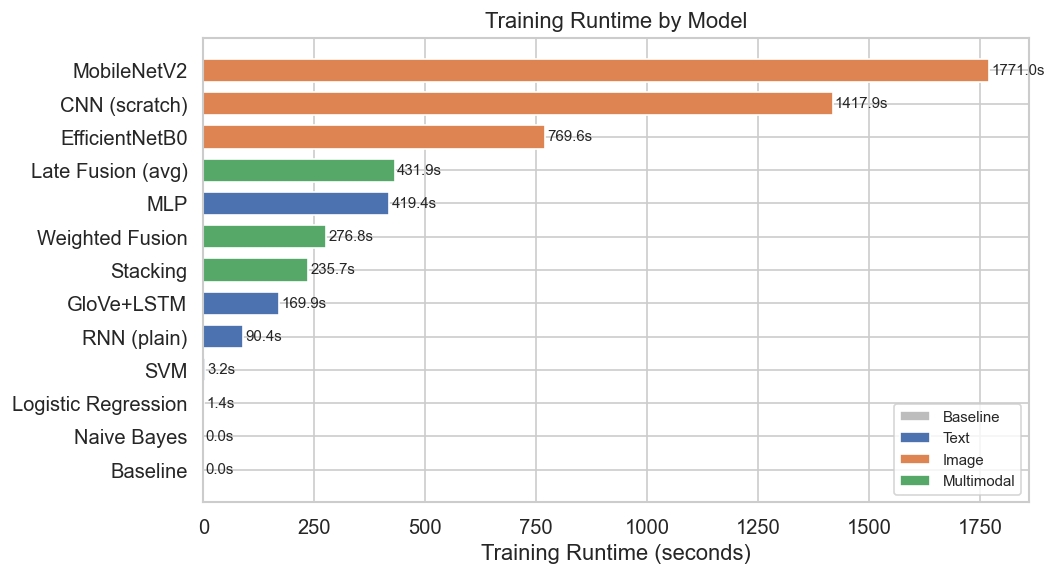

In [14]:
runtime_df = df.sort_values('Runtime (s)')

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(
    runtime_df['Model'], runtime_df['Runtime (s)'],
    color=[pipeline_palette[p] for p in runtime_df['Pipeline']], edgecolor='white', height=0.7
)
for i, (_, row) in enumerate(runtime_df.iterrows()):
    ax.text(row['Runtime (s)'] + 5, i, f"{row['Runtime (s)']:.1f}s", va='center', fontsize=9)
ax.set_xlabel('Training Runtime (seconds)')
ax.set_title('Training Runtime by Model')
legend_elements = [Patch(facecolor=pipeline_palette[p], label=p) for p in pipeline_order]
ax.legend(handles=legend_elements, fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()

## Chart 7 — Pipeline champions head-to-head

The single strongest model from each pipeline, side by side. This is the headline result:
text carries the most predictable sentiment, image the least, and multimodal fusion lands
at the text level (it cannot exceed text because the image modality adds no usable signal).

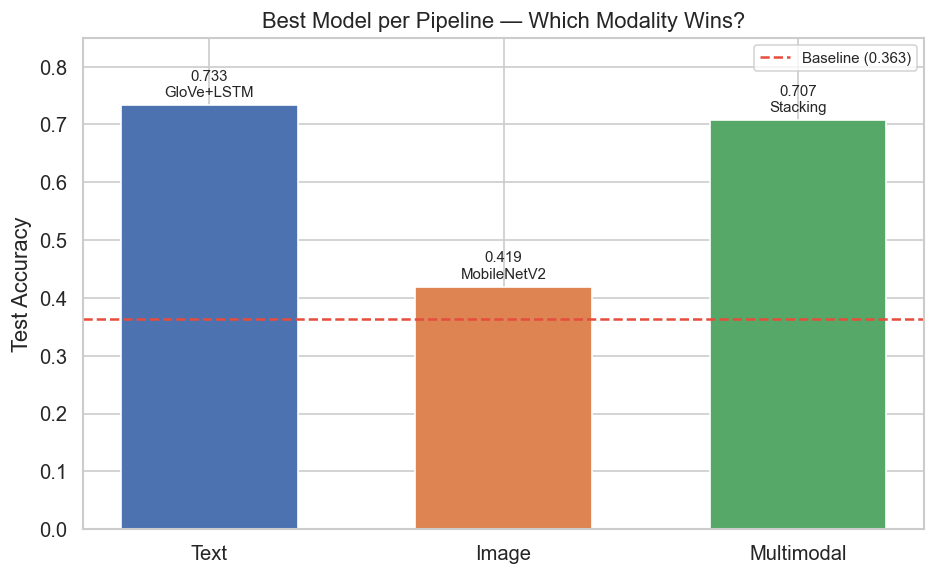

In [15]:
champ_plot = champions.copy()
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    champ_plot['Pipeline'].astype(str), champ_plot['Accuracy'],
    color=[pipeline_palette[p] for p in champ_plot['Pipeline'].astype(str)],
    edgecolor='white', width=0.6
)
ax.axhline(baseline_acc, color='#e74c3c', linestyle='--', linewidth=1.5,
           label=f'Baseline ({baseline_acc:.3f})')
for bar, (_, row) in zip(bars, champ_plot.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{row['Accuracy']:.3f}\n{row['Model']}", ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Test Accuracy')
ax.set_title('Best Model per Pipeline — Which Modality Wins?')
ax.set_ylim(0, 0.85)
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

## Chart 8 — Accuracy distribution per pipeline

Each point is one model. Shows not just the best model per pipeline but the full spread —
e.g. the image pipeline clusters tightly just above baseline, while the text pipeline
spans from a collapsed plain-RNN up to GloVe+LSTM.

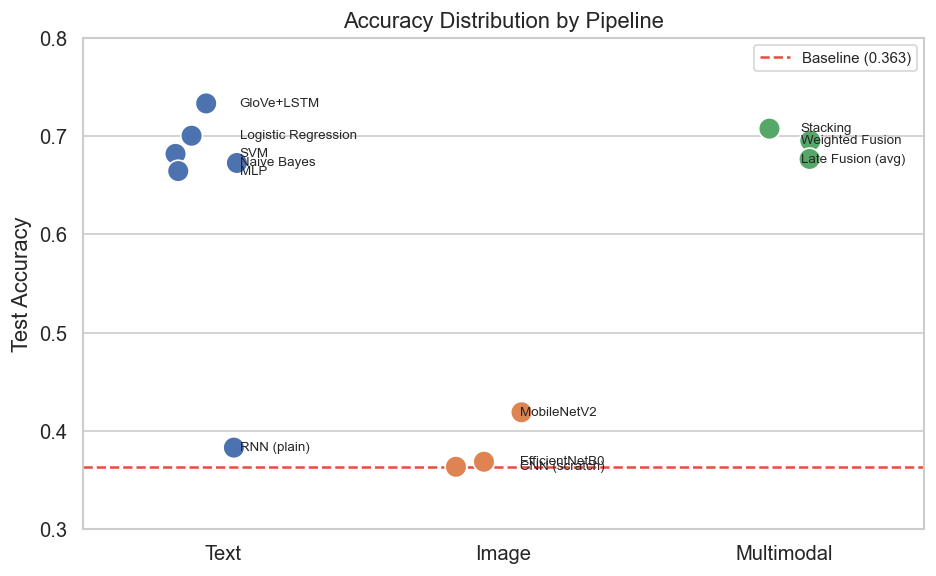

In [16]:
plot = df[df['Pipeline'] != 'Baseline'].copy()
plot['Pipeline'] = pd.Categorical(plot['Pipeline'], categories=['Text', 'Image', 'Multimodal'], ordered=True)

fig, ax = plt.subplots(figsize=(8, 5))
sns.stripplot(
    data=plot, x='Pipeline', y='Accuracy', hue='Pipeline',
    palette=pipeline_palette, size=13, jitter=0.18, edgecolor='white',
    linewidth=1, ax=ax, legend=False
)
ax.axhline(baseline_acc, color='#e74c3c', linestyle='--', linewidth=1.5,
           label=f'Baseline ({baseline_acc:.3f})')
for _, row in plot.iterrows():
    ax.annotate(row['Model'], (row['Pipeline'], row['Accuracy']),
                textcoords='offset points', xytext=(10, 0), fontsize=8, va='center')
ax.set_ylabel('Test Accuracy')
ax.set_xlabel('')
ax.set_title('Accuracy Distribution by Pipeline')
ax.set_ylim(0.3, 0.8)
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()